In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

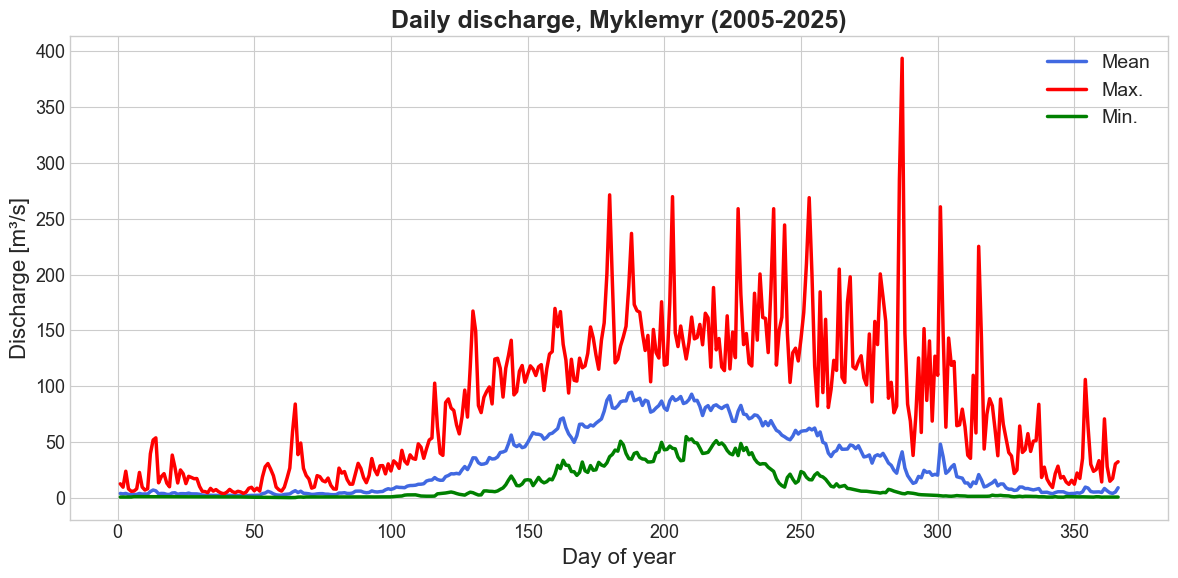

In [9]:
df = pd.read_csv("myklemyr.csv", sep=";", skiprows=1)
df["Vannføring (m³/s)"] = (
    df["Vannføring (m³/s)"]
    .str.replace(",", ".")
    .astype(float)
)
df["Tidspunkt"] = pd.to_datetime(df["Tidspunkt"])


df["doy"] = df["Tidspunkt"].dt.dayofyear

df_clim = df.groupby("doy")["Vannføring (m³/s)"].agg(
    mean="mean",
    max="max",
    min="min"
).reset_index()
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

plt.figure(figsize=(12, 6))

# # Min–max envelope
# plt.fill_between(
#     df_clim["doy"],
#     df_clim["min"],
#     df_clim["max"],
#     alpha=0.2,
#     label="Min–Max range"
# )

# Mean line
plt.plot(
    df_clim["doy"],
    df_clim["mean"],
    linewidth=2.5,
    c="royalblue",
    label="Mean"
)
plt.plot(
    df_clim["doy"],
    df_clim["max"],
    linewidth=2.5,
    c="r",
    label="Max."
)
plt.plot(
    df_clim["doy"],
    df_clim["min"],
    linewidth=2.5,
    c="green",
    label="Min."
)


# Labels
plt.xlabel("Day of year")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily discharge, Myklemyr (2005-2025)", weight="bold")

plt.legend()

plt.tight_layout()
plt.show()

### Making statistics 

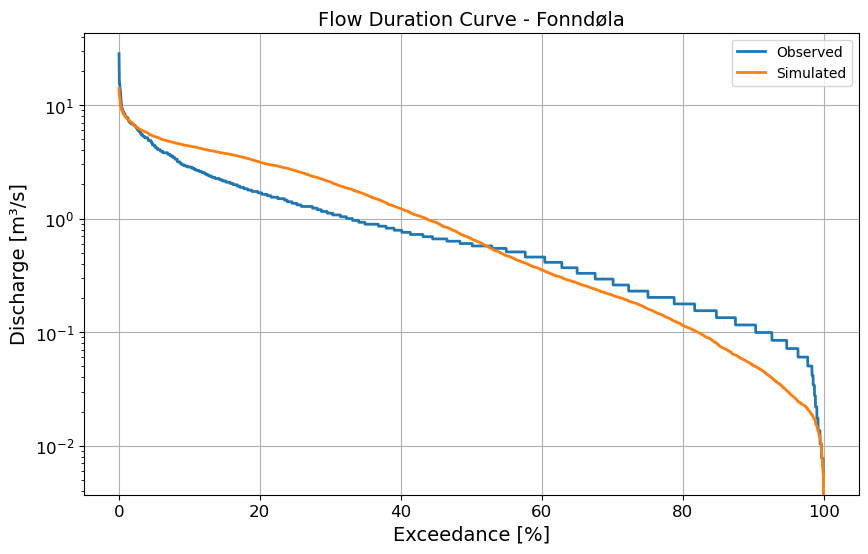

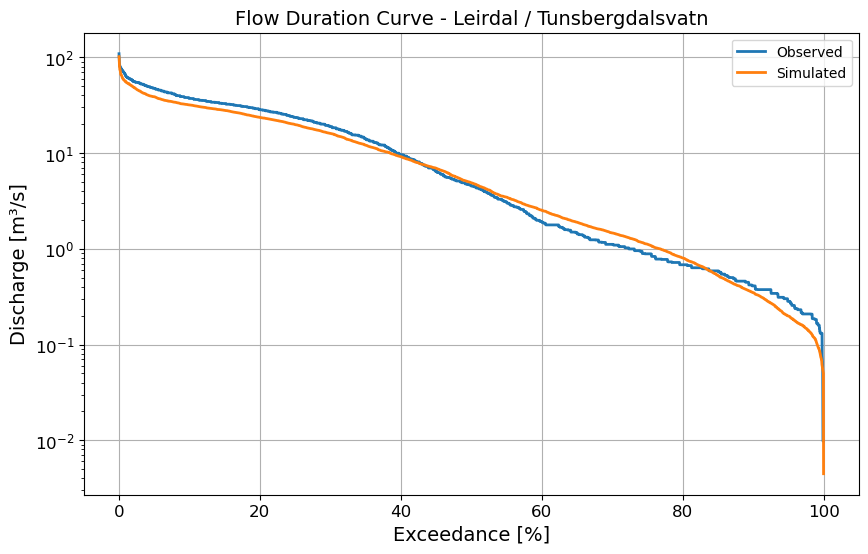

In [6]:
file_path = "C:\\Users\\Eline Karijord\\DDD-folder\\laptop_work\\DDDEcco\\outputs_Jostedal"

def load_qsim(filename):
    df = pd.read_csv(f"{file_path}\\{filename}", sep=";", skiprows=range(1,122))
    
    # Convert time columns
    for col in ["Yr", "Mnt", "Day", "Hr", "Min"]:
        df[col] = df[col].astype(int)
    
    # Create datetime
    df["datetime"] = pd.to_datetime(
        df[["Yr", "Mnt", "Day", "Hr", "Min"]]
        .astype(str)
        .agg("-".join, axis=1),
        format="%Y-%m-%d-%H-%M"
    )
    
    df.set_index("datetime", inplace=True)
    
    # Keep only Qsim
    return df[["Qsim"]]

Tunsbergdalsvatn = load_qsim("Tunsbergdalsvatnet_utfile_1H.csv").resample("D").mean()
Fonndøla = load_qsim("Fonndøla_utfile_1H.csv").resample("D").mean()


def load_obs(filename):
    df = pd.read_csv(filename, sep=";", skiprows=2, decimal=",")
    df.columns = ["time", "Qobs", "corr", "ctrl"]
    
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")
    
    return df[["Qobs"]]

obs_fonn = load_obs("fondola_vf.csv")
obs_leir = load_obs("leirdal_vf.csv")

obs_leir = obs_leir.loc[: "1975-10-15 11:00:00"]

Tunsbergdalsvatn_daily = Tunsbergdalsvatn.resample("D").mean()
Fonndola_daily = Fonndøla.resample("D").mean()


def compute_fdc(series):
    series = series.dropna().values
    
    # Sort descending
    sorted_flow = np.sort(series)[::-1]
    
    # Exceedance probability
    n = len(sorted_flow)
    exceedance = np.arange(1, n+1) / (n+1) * 100
    
    return exceedance, sorted_flow


plt.figure(figsize=(10,6))

# Observed
ex_obs, q_obs = compute_fdc(obs_fonn["Qobs"])
plt.plot(ex_obs, q_obs, label="Observed", linewidth=2)

# Simulated
ex_sim, q_sim = compute_fdc(Fonndola_daily["Qsim"])
plt.plot(ex_sim, q_sim, label="Simulated", linewidth=2)
plt.yscale("log")

plt.xlabel("Exceedance [%]", fontsize=14)
plt.ylabel("Discharge [m³/s]", fontsize=14)
plt.title("Flow Duration Curve - Fonndøla", fontsize=14)
plt.tick_params(labelsize=12)
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(10,6))

ex_obs, q_obs = compute_fdc(obs_leir["Qobs"])
plt.plot(ex_obs, q_obs, label="Observed", linewidth=2)

ex_sim, q_sim = compute_fdc(Tunsbergdalsvatn_daily["Qsim"])
plt.plot(ex_sim, q_sim, label="Simulated", linewidth=2)
plt.yscale("log")

plt.xlabel("Exceedance [%]", fontsize=14)
plt.ylabel("Discharge [m³/s]", fontsize=14)
plt.tick_params(labelsize=12)
plt.title("Flow Duration Curve - Leirdal / Tunsbergdalsvatn", fontsize=14)
plt.legend()
plt.grid(True)

plt.show()